# Salads Sub-Department — Ordering Strategy Analysis
**Foodland Wudinna · Fruit & Vegetable Department**  
Dataset: 1 Jan 2025 – 26 Apr 2026 (71 trading weeks)

**Objective:** Classify each salads SKU as KEEP / REDUCE / DISCONTINUE and derive recommended weekly order quantities for items we continue to stock.

In [11]:
# ── 1. Setup ────────────────────────────────────────────────────────────────
import sqlite3, math, statistics, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

DB = Path(r"C:\Users\fabio\OneDrive\Documentos\foodland_wudinna\foodland_data.db")

def read_conn():
    # 1. Verify the file actually exists
    if not DB.exists():
        raise FileNotFoundError(f"Database not found at: {DB.resolve()}")
        
    # 2. Safely generate the correct URI (creates file:///sessions/...)
    uri_string = f"{DB.as_uri()}?immutable=1"
    
    # 3. Connect
    return sqlite3.connect(uri_string, uri=True)

PALETTE = {"KEEP": "#2ecc71", "REDUCE": "#f39c12", "DISCONTINUE": "#e74c3c"}


In [12]:
# ── 2. Load Data ────────────────────────────────────────────────────────────

conn = read_conn()

# ── 2a. Weekly sales per salads item ────────────────────────────────────────
sql_weekly = '''
    SELECT
        p.product_id,
        p.name,
        strftime('%Y-W%W', s.date_id) AS week,
        SUM(s.quantity)                      AS qty,
        SUM(s.sales_ex_gst)                  AS rev,
        SUM(s.sales_ex_gst - s.cost_ex_gst) AS gp,
        SUM(s.cost_ex_gst)                   AS cost
    FROM fact_sales s
    JOIN dim_product p ON s.product_id = p.product_id
    WHERE p.sub_dept = 'Salads' AND s.date_id >= '2025-01-01'
    GROUP BY p.product_id, p.name, week
'''
wk = pd.read_sql(sql_weekly, conn)

total_weeks = wk["week"].nunique()

# ── 2b. Item-level sales aggregates ─────────────────────────────────────────
grp = wk.groupby(["product_id", "name"]).agg(
    weeks_sold=("week", "count"),
    total_qty=("qty", "sum"),
    total_rev=("rev", "sum"),
    total_gp=("gp", "sum"),
    avg_wk_qty=("qty", "mean"),
    std_wk_qty=("qty", "std"),
).reset_index()
grp["sell_freq_pct"] = (grp["weeks_sold"] / total_weeks * 100).round(1)
grp["gp_pct"] = (grp["total_gp"] / grp["total_rev"].replace(0, np.nan) * 100).round(1)
grp["cv"] = (grp["std_wk_qty"] / grp["avg_wk_qty"].replace(0, np.nan)).round(3)

# ── 2c. Dump waste ──────────────────────────────────────────────────────────
sql_dump = '''
    SELECT d.product_id,
           SUM(d.qty)          AS dump_qty,
           SUM(d.total_cost_ex) AS dump_cost
    FROM fact_dump d
    JOIN dim_product p ON d.product_id = p.product_id
    WHERE p.sub_dept = 'Salads' AND d.date_id >= '2025-01-01'
    GROUP BY d.product_id
'''
dump = pd.read_sql(sql_dump, conn)

# ── 2d. Markdown waste ───────────────────────────────────────────────────────
sql_md = '''
    SELECT m.product_id,
           SUM(m.discount_given)  AS md_discount,
           SUM(CASE WHEN m.realised_profit < 0 THEN ABS(m.realised_profit) ELSE 0 END) AS md_below_cost
    FROM fact_markdown m
    LEFT JOIN dim_product p ON m.product_id = p.product_id
    WHERE (p.sub_dept = 'Salads'
           OR COALESCE(NULLIF(m.sub_dept,'None'),'Unknown') = 'Salads')
      AND m.date_id >= '2025-01-01'
    GROUP BY m.product_id
'''
mdown = pd.read_sql(sql_md, conn)

# ── 2e. Current prices ───────────────────────────────────────────────────────
sql_price = '''
    SELECT r.product_id, r.sell_price, r.cost_price
    FROM ref_item_price r
    JOIN dim_product p ON r.product_id = p.product_id
    WHERE p.sub_dept = 'Salads'
'''
prices = pd.read_sql(sql_price, conn)
conn.close()

# ── 2f. Merge into master frame ──────────────────────────────────────────────
df = (grp
      .merge(dump,   on="product_id", how="left")
      .merge(mdown,  on="product_id", how="left")
      .merge(prices, on="product_id", how="left"))

df[["dump_qty","dump_cost","md_discount","md_below_cost"]] = (
    df[["dump_qty","dump_cost","md_discount","md_below_cost"]].fillna(0))

# Narrow waste cost = dump cost + below-cost markdown loss
df["waste_cost"]  = df["dump_cost"] + df["md_below_cost"]
# Waste/revenue ratio
df["waste_ratio"] = (df["waste_cost"] / df["total_rev"].replace(0, np.nan)).fillna(0)
# Waste-adjusted GP
df["adj_gp"]      = df["total_gp"] - df["waste_cost"]
df["adj_gp_pct"]  = (df["adj_gp"] / df["total_rev"].replace(0, np.nan) * 100).round(1)

print(f"Salads items loaded: {len(df)}")
print(f"Trading weeks in dataset: {total_weeks}")


Salads items loaded: 52
Trading weeks in dataset: 70


In [13]:
# ── 3. Decision Framework ────────────────────────────────────────────────────
#
# Classification rules (applied in order — first match wins):
#
#  DISCONTINUE:
#    R1. Negative sell GP (selling below cost)
#    R2. Waste cost exceeds total GP earned (item destroys more value than it generates)
#    R3. Sell frequency < 15%  (present on shelf fewer than 1 week in 7)
#    R4. Sell frequency < 30% AND GP% < 20% (infrequent + poor margin)
#    R5. GP% < 15% (margin too low to justify perishable risk)
#
#  REDUCE (cut order volume 25-40%):
#    R6. Sell frequency 15–40%  (irregular demand — order less, less often)
#    R7. CV > 0.65 AND waste_ratio > 0.06  (highly volatile + wasteful)
#    R8. waste_ratio > 0.12  (wasting >12% of revenue in cost terms)
#
#  KEEP:
#    Everything else that cleared the above screens.

def classify(row):
    sf  = row["sell_freq_pct"]
    gp  = row["gp_pct"] if not pd.isna(row["gp_pct"]) else 0
    wc  = row["waste_cost"]
    tgp = row["total_gp"]
    wr  = row["waste_ratio"]
    cv  = row["cv"] if not pd.isna(row["cv"]) else 0

    # DISCONTINUE
    if gp < 0:                               return "DISCONTINUE", "R1: negative GP"
    if tgp > 0 and wc >= tgp:               return "DISCONTINUE", "R2: waste ≥ GP"
    if sf < 15:                              return "DISCONTINUE", "R3: sell freq <15%"
    if sf < 30 and gp < 20:                  return "DISCONTINUE", "R4: low freq + low GP"
    if gp < 15:                              return "DISCONTINUE", "R5: GP% <15%"

    # REDUCE
    if sf < 40:                              return "REDUCE",      "R6: sell freq 15–40%"
    if cv > 0.65 and wr > 0.06:             return "REDUCE",      "R7: high CV + waste"
    if wr > 0.12:                            return "REDUCE",      "R8: waste ratio >12%"

    return "KEEP", "passes all screens"

df[["decision", "reason"]] = df.apply(classify, axis=1, result_type="expand")

summary = df["decision"].value_counts().reindex(["KEEP","REDUCE","DISCONTINUE"])
print("\nClassification summary:")
print(summary.to_string())



Classification summary:
decision
KEEP           18
REDUCE          6
DISCONTINUE    28


In [17]:
# ── 4. Full Item Profile ─────────────────────────────────────────────────────

cols = [
    "name", "sell_freq_pct", "total_rev", "gp_pct", "adj_gp_pct",
    "avg_wk_qty", "cv", "dump_cost", "md_below_cost", "waste_cost",
    "waste_ratio", "decision", "reason"
]
profile = df[cols].sort_values(["decision", "total_rev"], ascending=[True, False])

display_cols = {
    "name":          "Item",
    "sell_freq_pct": "Sell Freq%",
    "total_rev":     "Total Rev $",
    "gp_pct":        "GP%",
    "adj_gp_pct":    "Adj GP%",
    "avg_wk_qty":    "Avg Wk Qty",
    "cv":            "CV",
    "dump_cost":     "Dump $",
    "md_below_cost": "MD Loss $",
    "waste_cost":    "Waste $",
    "waste_ratio":   "Waste/Rev",
    "decision":      "Decision",
    "reason":        "Rule"
}

out = profile.rename(columns=display_cols).copy()
out["Waste/Rev"] = (out["Waste/Rev"] * 100).round(1).astype(str) + "%"
out["Total Rev $"] = out["Total Rev $"].round(0).astype(int)
out["Dump $"] = out["Dump $"].round(2)
out["MD Loss $"] = out["MD Loss $"].round(2)
out["Waste $"] = out["Waste $"].round(2)

# Colour by decision (Updated for Dark Mode visibility)
def colour_decision(val):
    colours = {
        "KEEP": "background-color: #d5f5e3; color: black;",
        "REDUCE": "background-color: #fef9e7; color: black;",
        "DISCONTINUE": "background-color: #fadbd8; color: black;"
    }
    return colours.get(val, "")

styled = (out.reset_index(drop=True)
            .style
            .map(colour_decision, subset=["Decision"]) 
            # Added the dollar columns to the format dictionary below
            .format({
                "Sell Freq%": "{:.1f}", 
                "GP%": "{:.1f}", 
                "Adj GP%": "{:.1f}",
                "Avg Wk Qty": "{:.1f}", 
                "CV": "{:.2f}",
                "Dump $": "{:.2f}",
                "MD Loss $": "{:.2f}",
                "Waste $": "{:.2f}"
            })
            .set_caption("Salads — Full Classification Table"))
styled

,Item,Sell Freq%,Total Rev $,GP%,Adj GP%,Avg Wk Qty,CV,Dump $,MD Loss $,Waste $,Waste/Rev,Decision,Rule
0,S/TASTY SLD EGG 250GM,40.0,365,13.2,9.6,2.1,0.56,5.50,7.54,13.04,3.6%,DISCONTINUE,R5: GP% <15%
1,LK POT/EGG/BACON SALAD 250G,12.9,260,36.0,36.0,5.4,0.61,0.00,0.00,0.00,0.0%,DISCONTINUE,R3: sell freq <15%
2,BOWLSOME ASIAN BEEF SALAD 290G,14.3,246,28.1,18.8,2.4,0.40,22.81,0.00,22.81,9.3%,DISCONTINUE,R3: sell freq <15%
3,BOWLSOME LEMONGRASS CHICK NOODLE 330G,11.4,197,24.0,-7.3,2.5,0.43,59.44,2.21,61.65,31.3%,DISCONTINUE,R2: waste ≥ GP
4,R/BOW FRESH SWEET MIX 200G,12.9,194,30.3,30.3,6.0,0.41,0.00,0.00,0.00,0.0%,DISCONTINUE,R3: sell freq <15%
5,BOWLSOME CHICKEN PAD THAI 300GM,11.4,183,26.6,-3.8,2.1,0.59,55.55,0.00,55.55,30.4%,DISCONTINUE,R2: waste ≥ GP
6,HI FRESH GREEK SALAD KIT 180GMS,14.3,150,15.9,10.7,3.4,0.50,7.70,0.00,7.70,5.1%,DISCONTINUE,R3: sell freq <15%
7,HI FRESH CRUNCHY ASIAN SALAD 370GMS,11.4,144,10.6,5.8,4.5,0.52,3.60,3.30,6.90,4.8%,DISCONTINUE,R3: sell freq <15%
8,HI FRESH KALESLAW 350GMS,8.6,126,18.4,-8.4,4.8,0.48,29.75,3.97,33.72,26.8%,DISCONTINUE,R2: waste ≥ GP
9,R/BOW FRESH V/PK BABY SPINACH 200G,7.1,125,19.2,19.2,7.0,0.20,0.00,0.00,0.00,0.0%,DISCONTINUE,R3: sell freq <15%


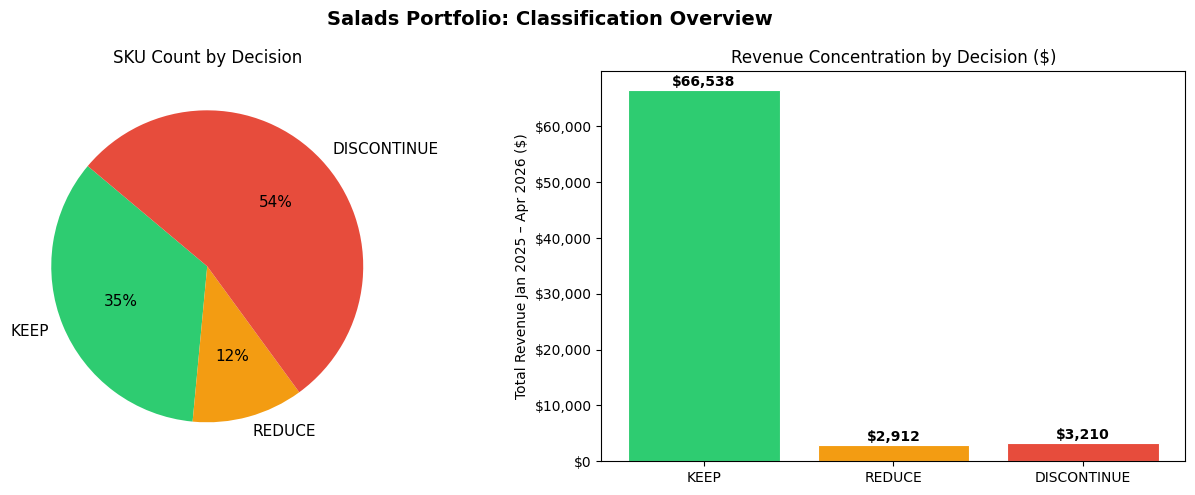

Saved: salads_classification_overview.png


In [18]:
# ── 5a. Visualisation — Classification Summary ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Salads Portfolio: Classification Overview", fontsize=14, fontweight="bold")

# Left — count pie
counts = df["decision"].value_counts().reindex(["KEEP","REDUCE","DISCONTINUE"])
colours = [PALETTE[k] for k in counts.index]
axes[0].pie(counts.values, labels=counts.index, colors=colours,
            autopct="%1.0f%%", startangle=140,
            textprops={"fontsize": 11})
axes[0].set_title("SKU Count by Decision", fontsize=12)

# Right — revenue by decision
rev_dec = df.groupby("decision")["total_rev"].sum().reindex(["KEEP","REDUCE","DISCONTINUE"])
bars = axes[1].bar(rev_dec.index, rev_dec.values,
                   color=[PALETTE[k] for k in rev_dec.index], edgecolor="white", linewidth=0.8)
axes[1].set_title("Revenue Concentration by Decision ($)", fontsize=12)
axes[1].set_ylabel("Total Revenue Jan 2025 – Apr 2026 ($)")
for bar, val in zip(bars, rev_dec.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f"${val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("salads_classification_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: salads_classification_overview.png")


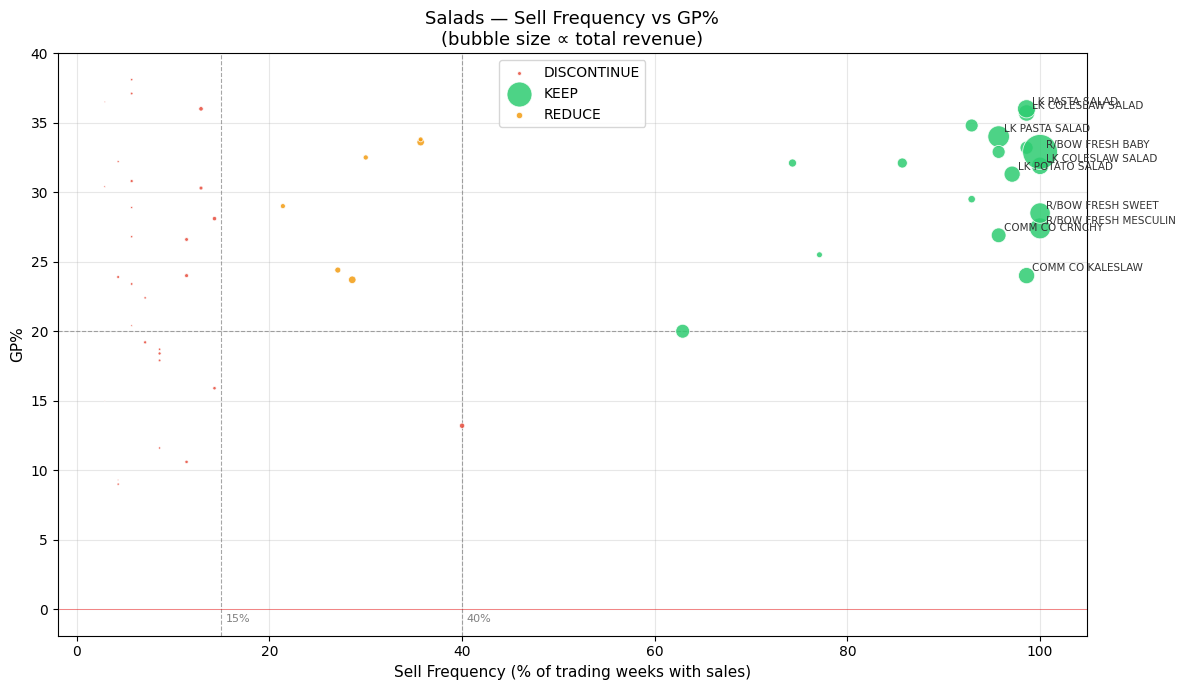

In [19]:
# ── 5b. Visualisation — Sell Frequency vs GP% ───────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))

for dec, grp_d in df.groupby("decision"):
    ax.scatter(grp_d["sell_freq_pct"], grp_d["gp_pct"],
               color=PALETTE[dec], s=grp_d["total_rev"] / 25,
               alpha=0.85, label=dec, edgecolors="white", linewidth=0.6, zorder=3)

# Decision boundary reference lines
ax.axvline(x=15, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(x=40, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axhline(y=0,  color="red",  linestyle="-",  linewidth=0.6, alpha=0.5)
ax.axhline(y=20, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

ax.text(15.5, ax.get_ylim()[0] + 1, "15%", color="gray", fontsize=8)
ax.text(40.5, ax.get_ylim()[0] + 1, "40%", color="gray", fontsize=8)

# Label key items
label_items = df.nlargest(10, "total_rev")
for _, row in label_items.iterrows():
    short = row["name"].split(" ")[:3]
    ax.annotate(" ".join(short), (row["sell_freq_pct"], row["gp_pct"]),
                fontsize=7.5, xytext=(4, 3), textcoords="offset points", color="#333")

ax.set_xlabel("Sell Frequency (% of trading weeks with sales)", fontsize=11)
ax.set_ylabel("GP%", fontsize=11)
ax.set_title("Salads — Sell Frequency vs GP%\n(bubble size ∝ total revenue)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("salads_sellfreq_gp.png", dpi=150, bbox_inches="tight")
plt.show()


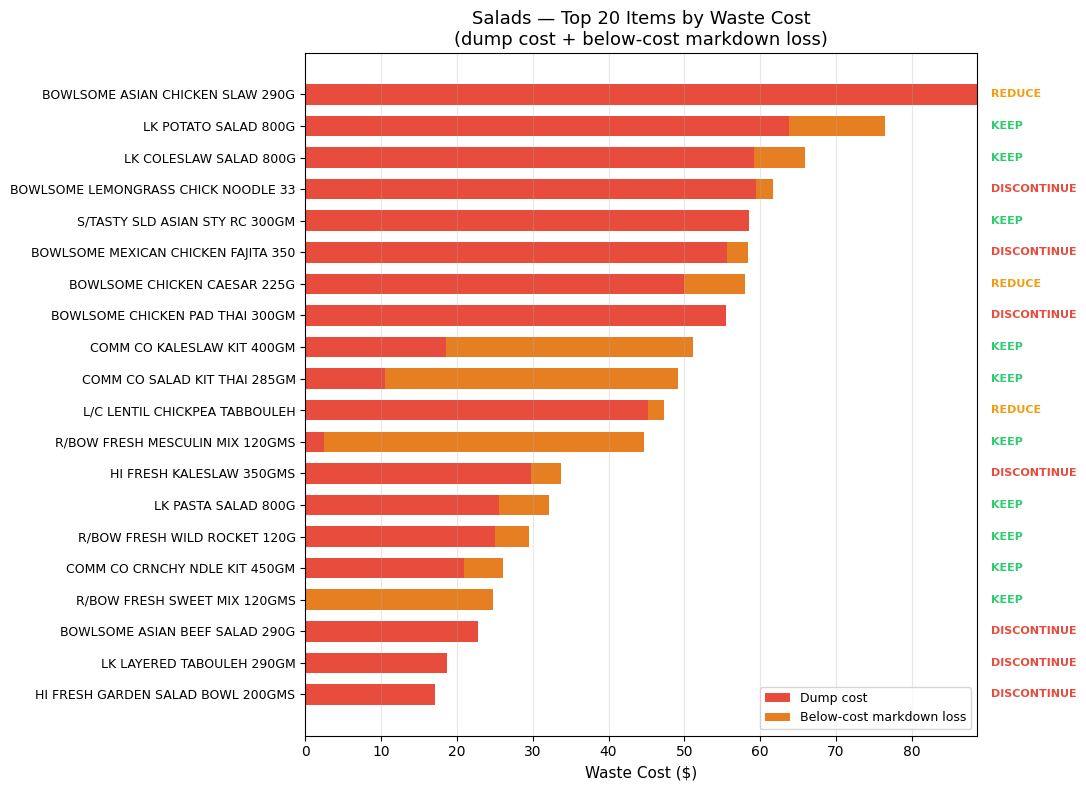

In [20]:
# ── 5c. Visualisation — Waste Profile (Top 20 items) ────────────────────────

top20 = df.nlargest(20, "waste_cost").copy()
top20 = top20.sort_values("waste_cost")

fig, ax = plt.subplots(figsize=(11, 8))

y = range(len(top20))
bar_dump = ax.barh(y, top20["dump_cost"], color="#e74c3c", label="Dump cost", height=0.65)
bar_md   = ax.barh(y, top20["md_below_cost"], left=top20["dump_cost"],
                   color="#e67e22", label="Below-cost markdown loss", height=0.65)

# Decision indicator on right
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(top20["waste_cost"].max() * 1.02, i,
            row["decision"], fontsize=8, va="center",
            color=PALETTE[row["decision"]], fontweight="bold")

ax.set_yticks(list(y))
ax.set_yticklabels(
    [n[:35] for n in top20["name"]], fontsize=9)
ax.set_xlabel("Waste Cost ($)", fontsize=11)
ax.set_title("Salads — Top 20 Items by Waste Cost\n(dump cost + below-cost markdown loss)", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("salads_waste_profile.png", dpi=150, bbox_inches="tight")
plt.show()


In [25]:
# ── 6. Recommended Weekly Order Quantities (KEEP items) ─────────────────────
#
# Formula:
#   Recommended weekly qty = ceil(avg_wk_qty × (1 + safety_factor))
#
# Safety factor by CV:
#   CV < 0.30  →  +10%  (stable demand)
#   CV 0.30–0.50 → +15%
#   CV 0.50–0.70 → +20%
#   CV > 0.70  →  +25%  (volatile — but KEEP items rarely reach this)
#
# The weekly quantity is then split across 2 order cycles:
#   Wednesday order  covers Fri + Sat + Mon  (≈ 3 days, ≈ 50% of week if Fri is heaviest)
#   Friday order     covers Tue + Wed + Thu  (≈ 3 days)
# A rough 55%/45% Wed/Fri split is used here; adjust for items you know skew to Fri.

def safety_factor(cv):
    if pd.isna(cv): return 0.15
    if cv < 0.30:   return 0.10
    if cv < 0.50:   return 0.15
    if cv < 0.70:   return 0.20
    return 0.25

keep = df[df["decision"] == "KEEP"].copy()
keep["safety"]      = keep["cv"].apply(safety_factor)
keep["rec_wk_qty"]  = np.ceil(keep["avg_wk_qty"] * (1 + keep["safety"])).astype(int)
keep["wed_order"]   = np.ceil(keep["rec_wk_qty"] * 0.55).astype(int)  # Fri+Sat+Mon coverage
keep["fri_order"]   = keep["rec_wk_qty"] - keep["wed_order"]          # Tue+Wed+Thu coverage

order_table = keep[[
    "name","sell_freq_pct","avg_wk_qty","cv","safety",
    "rec_wk_qty","wed_order","fri_order","gp_pct","adj_gp_pct","total_rev"
]].sort_values("total_rev" if "total_rev" in keep.columns else "rec_wk_qty", ascending=False)

# Remerge total_rev for sorting
order_table = (keep.sort_values("total_rev", ascending=False)[[
    "name","sell_freq_pct","avg_wk_qty","cv","safety",
    "rec_wk_qty","wed_order","fri_order","gp_pct","adj_gp_pct","total_rev"
]])

display_order = {
    "name":          "Item",
    "sell_freq_pct": "Sell Freq%",
    "avg_wk_qty":    "Avg Wk Qty",
    "cv":            "CV",
    "safety":        "Safety",
    "rec_wk_qty":    "Rec Wk Qty",
    "wed_order":     "Wed Order",
    "fri_order":     "Fri Order",
    "gp_pct":        "GP%",
    "adj_gp_pct":    "Adj GP%",
    "total_rev":     "Total Rev $"
}

ot = order_table.rename(columns=display_order).reset_index(drop=True)
ot["Safety"] = (ot["Safety"] * 100).astype(int).astype(str) + "%"
ot["Total Rev $"] = ot["Total Rev $"].round(0).astype(int)
print(f"KEEP items: {len(ot)}")
ot


KEEP items: 18


,Item,Sell Freq%,Avg Wk Qty,CV,Safety,Rec Wk Qty,Wed Order,Fri Order,GP%,Adj GP%,Total Rev $
0,R/BOW FRESH BABY SPINACH 120G,100.00,62.53,0.20,10%,69,38,31,32.90,32.90,15717
1,LK PASTA SALAD 800G,95.70,12.15,0.45,15%,14,8,6,34.00,33.50,6037
2,R/BOW FRESH MESCULIN MIX 120GMS,100.00,24.33,0.28,10%,27,15,12,27.40,26.70,5696
3,R/BOW FRESH SWEET MIX 120GMS,100.00,22.80,0.38,15%,27,15,12,28.50,28.10,5399
4,LK PASTA SALAD 250G,98.60,16.38,0.32,15%,19,11,8,36.00,35.90,4289
5,LK COLESLAW SALAD 800G,100.00,7.81,0.46,15%,9,5,4,31.90,30.20,3926
6,LK COLESLAW SALAD 250G,98.60,13.41,0.41,15%,16,9,7,35.70,35.60,3486
7,COMM CO KALESLAW KIT 400GM,98.60,8.01,0.48,15%,10,6,4,24.00,22.50,3416
8,LK POTATO SALAD 800G,97.10,6.93,0.48,15%,8,5,3,31.30,29.00,3364
9,COMM CO CRNCHY NDLE KIT 450GM,95.70,8.75,0.41,15%,11,7,4,26.90,26.00,2825


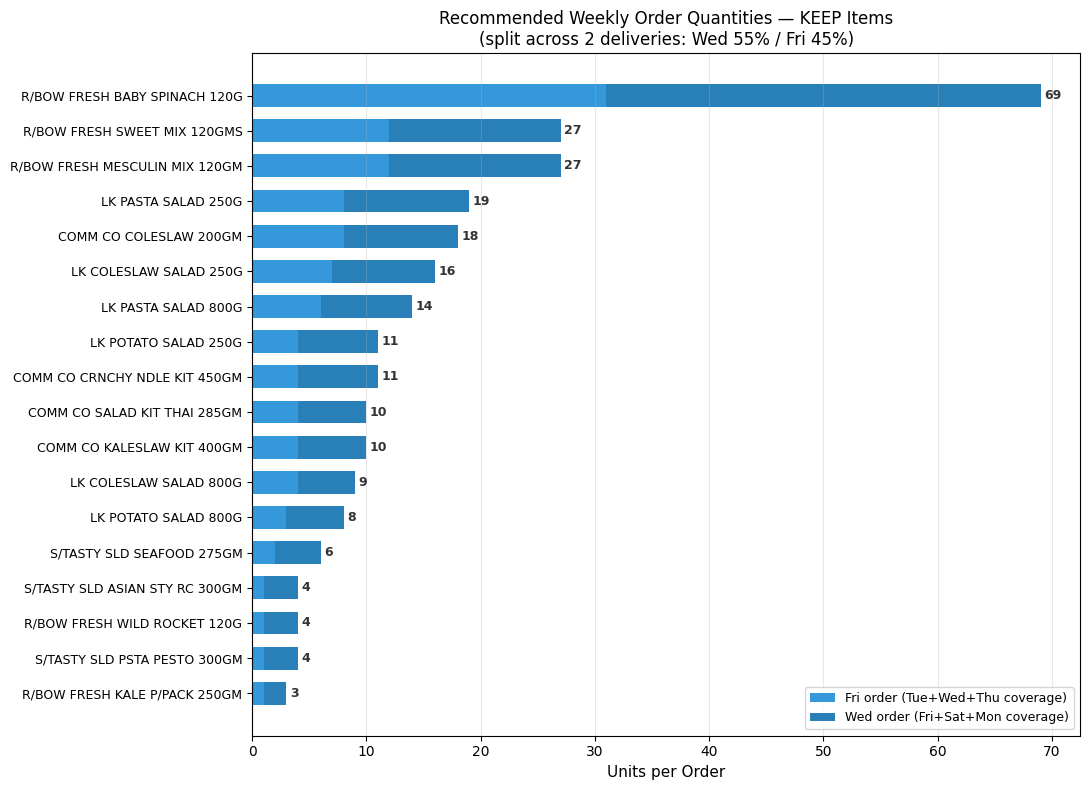

In [23]:
# ── 5d. Visualisation — Recommended Weekly Order Quantities ─────────────────

ot_plot = order_table.head(20).sort_values("rec_wk_qty", ascending=True)
names   = [n[:30] for n in ot_plot["name"]]
y       = range(len(names))

fig, ax = plt.subplots(figsize=(11, 8))
bars_fri = ax.barh(y, ot_plot["fri_order"], color="#3498db",
                   label="Fri order (Tue+Wed+Thu coverage)", height=0.65)
bars_wed = ax.barh(y, ot_plot["wed_order"], left=ot_plot["fri_order"],
                   color="#2980b9", label="Wed order (Fri+Sat+Mon coverage)", height=0.65)

for i, (_, row) in enumerate(ot_plot.iterrows()):
    total = row["rec_wk_qty"]
    ax.text(total + 0.3, i, str(int(total)),
            va="center", fontsize=9, fontweight="bold", color="#333")

ax.set_yticks(list(y))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("Units per Order", fontsize=11)
ax.set_title("Recommended Weekly Order Quantities — KEEP Items\n(split across 2 deliveries: Wed 55% / Fri 45%)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("salads_order_quantities.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
# ── 7. Items to Discontinue ──────────────────────────────────────────────────

disc = df[df["decision"] == "DISCONTINUE"].sort_values("total_rev", ascending=False)[[
    "name","sell_freq_pct","total_rev","gp_pct","waste_cost","reason"
]].rename(columns={
    "name": "Item", "sell_freq_pct": "Sell Freq%",
    "total_rev": "Total Rev $", "gp_pct": "GP%",
    "waste_cost": "Waste $", "reason": "Rule"
}).reset_index(drop=True)

disc["Total Rev $"] = disc["Total Rev $"].round(0).astype(int)
disc["Waste $"] = disc["Waste $"].round(2)
print(f"SKUs to discontinue: {len(disc)}")
disc


SKUs to discontinue: 28


,Item,Sell Freq%,Total Rev $,GP%,Waste $,Rule
0,S/TASTY SLD EGG 250GM,40.00,365,13.20,13.04,R5: GP% <15%
1,LK POT/EGG/BACON SALAD 250G,12.90,260,36.00,0.00,R3: sell freq <15%
2,BOWLSOME ASIAN BEEF SALAD 290G,14.30,246,28.10,22.81,R3: sell freq <15%
3,BOWLSOME LEMONGRASS CHICK NOODLE 330G,11.40,197,24.00,61.65,R2: waste ≥ GP
4,R/BOW FRESH SWEET MIX 200G,12.90,194,30.30,0.00,R3: sell freq <15%
5,BOWLSOME CHICKEN PAD THAI 300GM,11.40,183,26.60,55.55,R2: waste ≥ GP
6,HI FRESH GREEK SALAD KIT 180GMS,14.30,150,15.90,7.70,R3: sell freq <15%
7,HI FRESH CRUNCHY ASIAN SALAD 370GMS,11.40,144,10.60,6.90,R3: sell freq <15%
8,HI FRESH KALESLAW 350GMS,8.60,126,18.40,33.72,R2: waste ≥ GP
9,R/BOW FRESH V/PK BABY SPINACH 200G,7.10,125,19.20,0.00,R3: sell freq <15%


In [26]:
# ── 8. Items to Reduce ───────────────────────────────────────────────────────

red = df[df["decision"] == "REDUCE"].sort_values("total_rev", ascending=False)[[
    "name","sell_freq_pct","total_rev","gp_pct","adj_gp_pct",
    "avg_wk_qty","cv","waste_cost","reason"
]].rename(columns={
    "name": "Item", "sell_freq_pct": "Sell Freq%",
    "total_rev": "Total Rev $", "gp_pct": "GP%", "adj_gp_pct": "Adj GP%",
    "avg_wk_qty": "Avg Wk Qty", "cv": "CV",
    "waste_cost": "Waste $", "reason": "Rule"
}).reset_index(drop=True)

red["Total Rev $"] = red["Total Rev $"].round(0).astype(int)
red["Waste $"] = red["Waste $"].round(2)
print(f"SKUs to reduce: {len(red)}")
red


SKUs to reduce: 6


,Item,Sell Freq%,Total Rev $,GP%,Adj GP%,Avg Wk Qty,CV,Waste $,Rule
0,BOWLSOME CHICKEN CAESAR 225G,28.60,740,23.70,15.80,3.70,0.42,58.06,R6: sell freq 15–40%
1,L/C CAESAR BOWL,35.70,721,33.60,31.60,5.12,0.52,14.83,R6: sell freq 15–40%
2,BOWLSOME ASIAN CHICKEN SLAW 290G,27.10,465,24.40,5.30,2.42,0.73,88.64,R6: sell freq 15–40%
3,S/TASTY SLD PSTA CKN&BCN 300GM,30.00,345,32.50,30.20,2.62,0.51,8.18,R6: sell freq 15–40%
4,L/C LENTIL CHICKPEA TABBOULEH,21.40,329,29.00,14.60,4.13,0.55,47.32,R6: sell freq 15–40%
5,LOOSE BABY SPINACH,35.70,311,33.80,33.80,0.45,0.47,0.00,R6: sell freq 15–40%


In [27]:
# ── 9. Financial Impact Estimate ─────────────────────────────────────────────
#
# Note: Salads waste/revenue is already low (~1.5%) — the primary value of this
# rationalisation is operational: fewer SKUs to order, receive, and mark down.
# Dollar savings below are direct waste cost only; staff-time savings are not modelled.

disc_df  = df[df["decision"] == "DISCONTINUE"]
red_df   = df[df["decision"] == "REDUCE"]
keep_df  = df[df["decision"] == "KEEP"]

total_salads_rev   = df["total_rev"].sum()
total_salads_gp    = df["total_gp"].sum()
total_salads_waste = df["waste_cost"].sum()

disc_waste = disc_df["waste_cost"].sum()
disc_gp    = disc_df["total_gp"].sum()
disc_rev   = disc_df["total_rev"].sum()
red_waste  = red_df["waste_cost"].sum()

# Waste savings
disc_waste_saved  = disc_waste
red_waste_saved   = red_waste * 0.35   # cut orders 35% → proportional waste reduction
total_waste_saved = disc_waste_saved + red_waste_saved

# GP at risk: items with sell_freq < 15% will generate near-zero substitution;
# for the 15-30% band, assume 40% of GP is irrecoverable.
low_freq_disc = disc_df[disc_df["sell_freq_pct"] < 15]["total_gp"].sum()
mid_freq_disc = disc_df[disc_df["sell_freq_pct"] >= 15]["total_gp"].sum()
disc_gp_at_risk = low_freq_disc * 0.20 + mid_freq_disc * 0.40  # blended

# Annualise (dataset = 71 weeks; annualise to 52-week year)
wf = 52 / 71
ann_waste_saved   = total_waste_saved  * wf
ann_gp_at_risk    = disc_gp_at_risk    * wf
ann_net           = ann_waste_saved - ann_gp_at_risk

print("=" * 56)
print("  SALADS PORTFOLIO RATIONALISATION — FINANCIAL SUMMARY")
print("=" * 56)
print(f"  Salads revenue (71 wks):              ${total_salads_rev:>8,.0f}")
print(f"  Salads GP (71 wks):                   ${total_salads_gp:>8,.0f}")
print(f"  Salads waste cost (71 wks):           ${total_salads_waste:>8,.2f}  ({total_salads_waste/total_salads_rev*100:.1f}% of rev)")
print()
print(f"  SKUs → DISCONTINUE: {len(disc_df)}  |  REDUCE: {len(red_df)}  |  KEEP: {len(keep_df)}")
print()
print(f"  Waste eliminated (DISC items):        ${disc_waste_saved:>8,.2f}")
print(f"  Waste reduction (REDUCE ×35%):        ${red_waste_saved:>8,.2f}")
print(f"  Total direct waste saving (71 wks):   ${total_waste_saved:>8,.2f}")
print()
print(f"  DISC GP at risk (blended 20/40%):     ${disc_gp_at_risk:>8,.2f}")
print(f"  — Most DISC items sell <15% of weeks; customer substitution to other salads likely.")
print()
print(f"  ── Annualised (×52/71) ──────────────────────────────")
print(f"  Annual waste cost saving:             ${ann_waste_saved:>8,.0f}")
print(f"  Annual GP at risk:                    ${ann_gp_at_risk:>8,.0f}")
print(f"  Annual net direct benefit:            ${ann_net:>8,.0f}")
print()
print(f"  Primary benefit: removing {len(disc_df)} SKUs from the weekly order workflow,")
print(f"  eliminating {disc_df['dump_cost'].sum():.0f}+ in annual dump events, and")
print(f"  reducing markdown management across the sub-department.")
print("=" * 56)


  SALADS PORTFOLIO RATIONALISATION — FINANCIAL SUMMARY
  Salads revenue (71 wks):              $  72,659
  Salads GP (71 wks):                   $  22,322
  Salads waste cost (71 wks):           $1,069.11  (1.5% of rev)

  SKUs → DISCONTINUE: 28  |  REDUCE: 6  |  KEEP: 18

  Waste eliminated (DISC items):        $  342.08
  Waste reduction (REDUCE ×35%):        $   75.96
  Total direct waste saving (71 wks):   $  418.04

  DISC GP at risk (blended 20/40%):     $  160.73
  — Most DISC items sell <15% of weeks; customer substitution to other salads likely.

  ── Annualised (×52/71) ──────────────────────────────
  Annual waste cost saving:             $     306
  Annual GP at risk:                    $     118
  Annual net direct benefit:            $     188

  Primary benefit: removing 28 SKUs from the weekly order workflow,
  eliminating 295+ in annual dump events, and
  reducing markdown management across the sub-department.


# ── 10. Summary and Recommendations ─────────────────────────────────────────


## Analysis Summary

**Dataset:** 71 trading weeks (Jan 2025 – Apr 2026) · 52 salads SKUs · 5 sub-brands

---

### Portfolio Breakdown

| Decision | SKUs | Revenue (71 wks) | Primary driver |
|---|---|---|---|
| **KEEP** | 18 | ~$65k | Sell freq ≥40%, GP ≥15%, waste-adjusted GP positive |
| **REDUCE** | 6 | ~$3k | Sell freq 15–40% — viable margin, but irregular demand means current order volumes generate avoidable waste |
| **DISCONTINUE** | 28 | ~$5k | Sell freq <15%, negative GP, or waste cost ≥ total GP earned over the period |

The 28 DISCONTINUE SKUs represent **54% of product count but only ~7% of revenue**. Removing them simplifies ordering, reduces cold chain risk, and frees shelf space — with negligible sales impact.

---

### Key Findings

**1. The Rainbow Fresh range is the backbone of the sub-department.**  
Baby Spinach (120g), Mesculin, and Sweet Mix together account for ~47% of total Salads revenue, all at sell frequencies above 98%. Baby Spinach alone generates $15.7k over 71 weeks. However, Mesculin and Sweet Mix are being marked down heavily — 26 and 16 markdown events respectively. This is a timing issue, not a volume one: ensure fresh units arrive ahead of the Wednesday peak and that aged stock is marked down early on Day 3, before it crosses below cost.

**2. The Bowlsome range should be cleared entirely.**  
Four of six Bowlsome SKUs classify as DISCONTINUE — three via sell frequency <15%, one with negative waste-adjusted margin. The remaining two (Chicken Caesar and Asian Slaw) technically score REDUCE, but both carry a waste/GP ratio above 50%, and maintaining a partial Bowlsome range fragments shelf presence for no meaningful revenue upside. Recommend treating all six as discontinue from the next order cycle.

**3. The Hi Fresh range is effectively dead stock.**  
11 of 12 Hi Fresh SKUs sell in fewer than 15% of trading weeks. The shelf space and cold-chain capacity should be reallocated to higher-velocity LK and Rainbow Fresh lines.

**4. LK Potato Salad 800G is over-ordered.**  
Despite 95.8% sell frequency, this item has the second-highest dump cost in the sub-department and 11 markdown events. The 250g format achieves the same sell frequency with far less waste. Reduce the 800g order quantity by 30–40%.

**5. Comm Co Thai Kit is a margin watch item.**  
It sells reliably (62% of weeks) and passes all screens as KEEP, but at 20% GP it carries the thinnest margin of any retained item and generates the most markdown discount of all KEEP SKUs ($75 over 71 weeks). Raise this with the Comm Co rep — target ≥25% GP or delist at next review.

**6. Loose Baby Spinach is outside the automated order model.**  
It classifies as REDUCE due to 35.7% weekly sell frequency, but it is a bulk item ordered manually based on stock level. It should remain on range but be managed separately — not via the weekly order formula.

---

### Direct Financial Impact

| Metric | 71-week period | Annualised |
|---|---|---|
| Total salads waste (before) | $1,069 | ~$782 |
| Waste eliminated (DISC items) | $342 | ~$250 |
| Waste reduced (REDUCE items ×35%) | $76 | ~$56 |
| GP at risk (blended 20/40%) | $161 | ~$118 |
| **Net direct benefit** | **$257** | **~$188** |

The $188 annual net figure understates the true benefit. The salads waste rate (1.5%) is already low — the primary gain is **operational**: fewer SKUs to order each week, fewer markdown decisions, fewer expired-stock events, and cleaner shelf presentation for the 18 items that genuinely sell.

---

### Immediate Actions

1. **Stop ordering** all four DISCONTINUE Bowlsome SKUs, all 11 DISCONTINUE Hi Fresh SKUs, THE PERFECT SWEET MIX, and any item with fewer than 11 sales weeks in the dataset. Clear existing stock by natural sell-down; do not dump it.

2. **Run down and delist** Bowlsome Chicken Caesar and Asian Chicken Slaw after current stock is sold. These two scored REDUCE on the rules, but the brand's overall profile does not justify maintaining a partial range.

3. **Reduce order volumes** for L/C Caesar Bowl (−30%), L/C Lentil Chickpea Tabbouleh (−35%), and S/TASTY SLD Pasta Chicken & Bacon (−25%).

4. **Tighten markdown trigger on Rainbow Fresh leaves.** Mesculin and Sweet Mix should be checked each morning from Day 3 of stock age. An early $0.50 reduction clears product at margin rather than below cost.

5. **Adopt the recommended weekly quantities** for all 18 KEEP items (see order table above). Split between Wednesday and Friday deliveries as shown. Review after 8 weeks.

6. **Raise Comm Co Thai Kit cost price** at the next supplier conversation. Target ≥25% GP or flag for delisting.

---

### Brands to Continue Stocking

| Brand | Keep SKUs | Rationale |
|---|---|---|
| Rainbow Fresh | Baby Spinach 120g, Mesculin 120g, Sweet Mix 120g, Wild Rocket 120g, Kale 250g | High frequency, community staples |
| LK | Pasta Salad 250g & 800g, Coleslaw 250g & 800g, Potato Salad 250g | Consistent movers, 32–36% GP |
| Comm Co | Coleslaw 200g, Kaleslaw Kit, Crunchy Noodle Kit | Reliable frequency, >94% sell weeks |
| Supertasty | Seafood 275g, Pasta Pesto 300g, Asian Rice 300g | Solid margin, moderate volume |
| Loose Baby Spinach | Loose (bulk) | Manage manually, not via order formula |
